# Análise dos Resultados

Este notebook executa os experimentos do trabalho, carrega os resultados salvos em `results/` e produz gráficos para apoiar a discussão do relatório.

In [9]:
from pathlib import Path
import sys

import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments import run_kmeans_experiment, run_kmeans_sklearn_comparison, run_knn_experiment, run_knn_sklearn_comparison

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
TRAIN_FILE = ROOT / 'nba_treino.csv'
TEST_FILE = ROOT / 'nba_teste.csv'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

In [ ]:
knn_custom = run_knn_experiment(TRAIN_FILE, TEST_FILE, [2, 10, 50, 7], RESULTS_DIR / 'knn')
knn_sklearn = run_knn_sklearn_comparison(TRAIN_FILE, TEST_FILE, [2, 10, 50, 7], RESULTS_DIR / 'knn_sklearn')
kmeans_custom = run_kmeans_experiment(TRAIN_FILE, TEST_FILE, [2, 3], RESULTS_DIR / 'kmeans')
kmeans_sklearn = run_kmeans_sklearn_comparison(TRAIN_FILE, TEST_FILE, [2, 3], RESULTS_DIR / 'kmeans_sklearn')

len(knn_custom), len(knn_sklearn), len(kmeans_custom), len(kmeans_sklearn)

(9, 9, 9, 9)

In [11]:
knn_rows = []
for row in knn_custom:
    knn_rows.append({**row, 'origin': 'custom'})
for row in knn_sklearn:
    knn_rows.append({**row, 'origin': 'sklearn'})

knn_df = pd.DataFrame(knn_rows)
knn_df[['origin', 'k', 'accuracy', 'precision', 'recall', 'f1']]

,origin,k,accuracy,precision,recall,f1
0,custom,2,0.589552,0.754386,0.511905,0.609929
1,custom,3,0.656716,0.726190,0.726190,0.726190
2,custom,4,0.608209,0.740458,0.577381,0.648829
3,custom,5,0.641791,0.719512,0.702381,0.710843
4,custom,6,0.619403,0.729167,0.625000,0.673077
5,custom,7,0.649254,0.725610,0.708333,0.716867
6,custom,8,0.652985,0.751678,0.666667,0.706625
7,custom,9,0.656716,0.726190,0.726190,0.726190
8,custom,10,0.652985,0.745098,0.678571,0.710280
9,sklearn,2,0.589552,0.754386,0.511905,0.609929


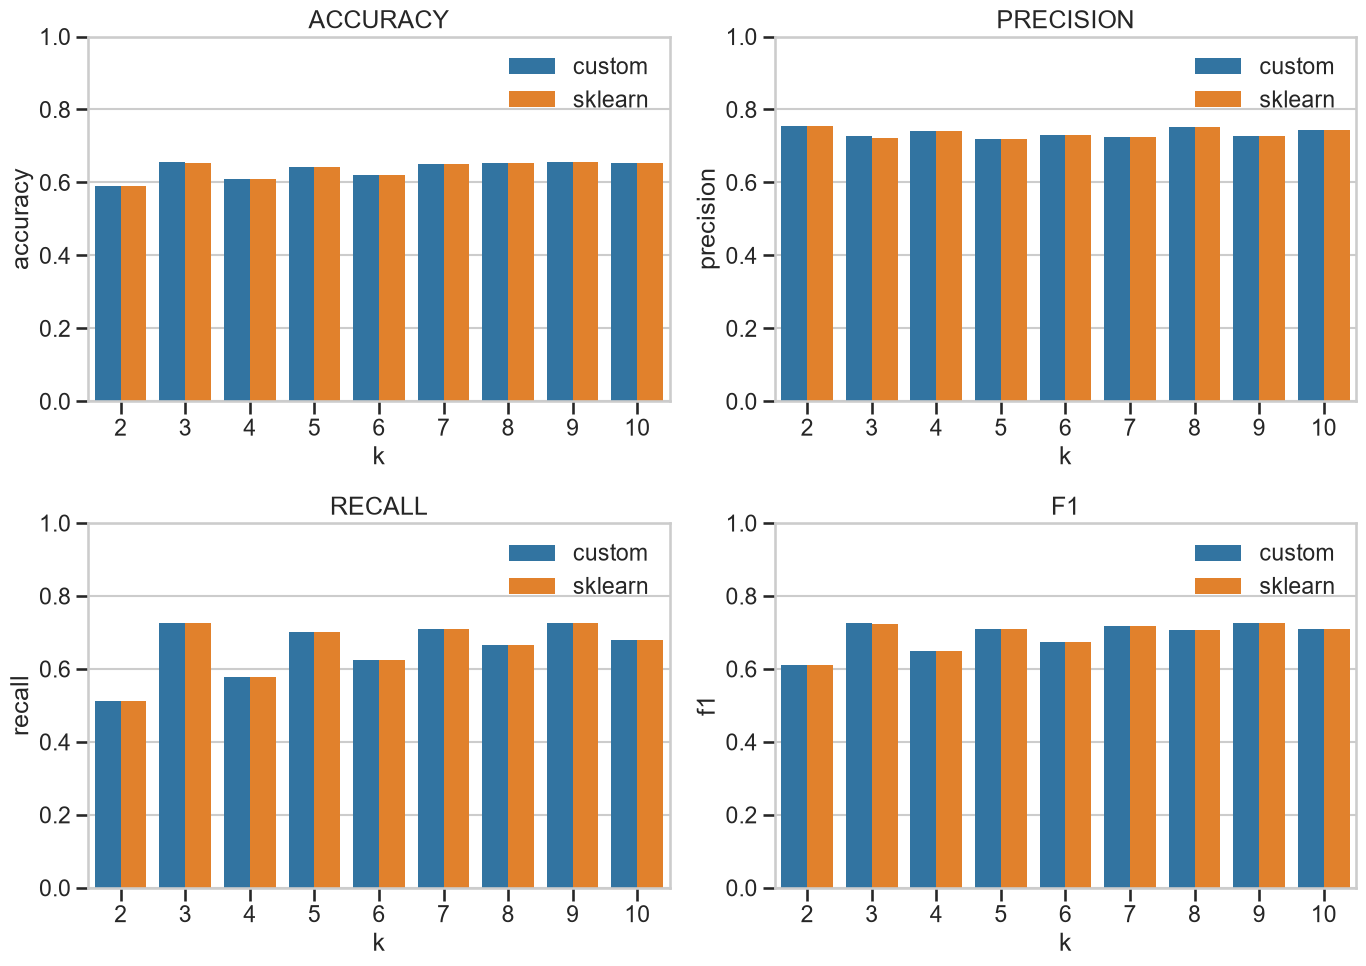

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1']
for ax, metric in zip(axes.flat, metrics):
    sns.barplot(data=knn_df, x='k', y=metric, hue='origin', ax=ax)
    ax.set_title(metric.upper())
    ax.set_ylim(0, 1)
    ax.legend(title='')
plt.tight_layout()

,pred_0,pred_1
true_0,72,28
true_1,82,86


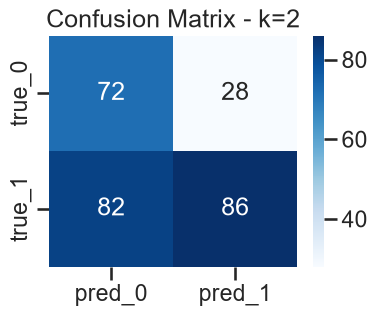

,pred_0,pred_1
true_0,54,46
true_1,46,122


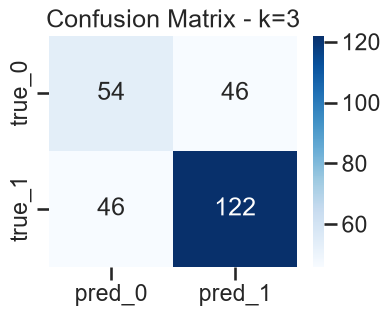

,pred_0,pred_1
true_0,66,34
true_1,71,97


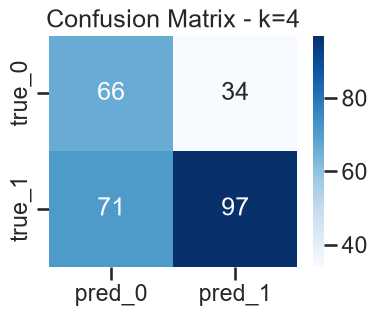

,pred_0,pred_1
true_0,54,46
true_1,50,118


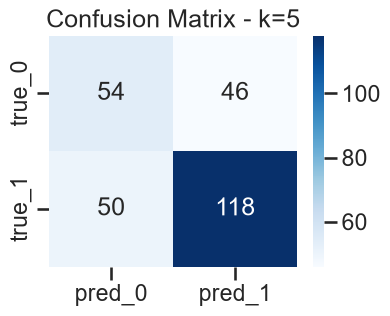

,pred_0,pred_1
true_0,61,39
true_1,63,105


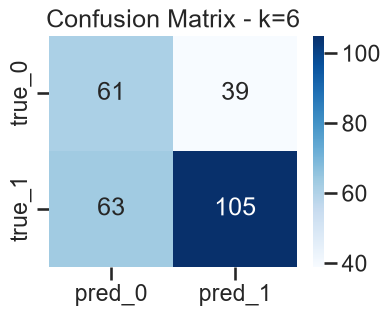

,pred_0,pred_1
true_0,55,45
true_1,49,119


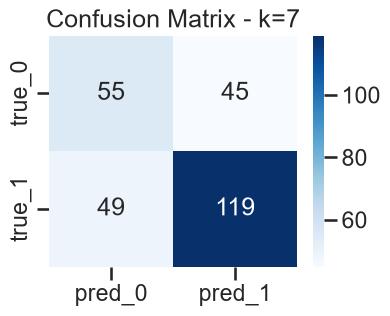

,pred_0,pred_1
true_0,63,37
true_1,56,112


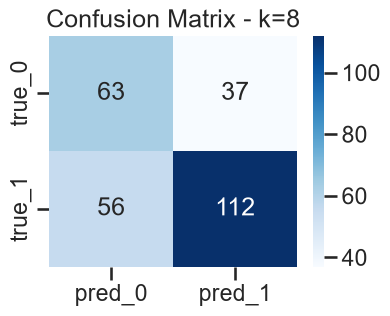

,pred_0,pred_1
true_0,54,46
true_1,46,122


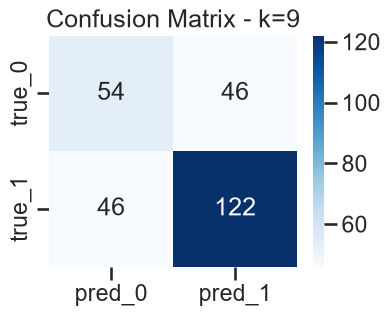

,pred_0,pred_1
true_0,61,39
true_1,54,114


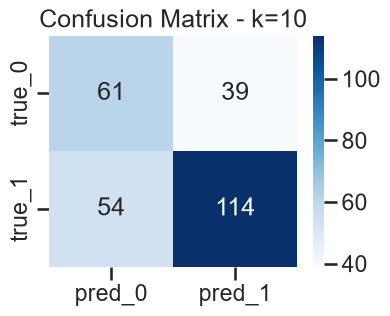

In [13]:
for result in knn_custom:
    matrix = pd.DataFrame(result['confusion_matrix'], index=['true_0', 'true_1'], columns=['pred_0', 'pred_1'])
    display(matrix)
    plt.figure(figsize=(4, 3))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - k={result['k']}")
    plt.show()

In [14]:
kmeans_rows = []
for row in kmeans_custom:
    kmeans_rows.append({'origin': 'custom', 'k': row['k'], 'clusters': row['cluster_summary']})
for row in kmeans_sklearn:
    kmeans_rows.append({'origin': 'sklearn', 'k': row['k'], 'clusters': row['cluster_summary']})
kmeans_rows

[{'origin': 'custom',
  'k': 2,
  'clusters': {0: {0: 68, 1: 441}, 1: {0: 362, 1: 469}}},
 {'origin': 'custom',
  'k': 3,
  'clusters': {0: {0: 16, 1: 137, 2: 356}, 1: {0: 152, 1: 387, 2: 292}}},
 {'origin': 'custom',
  'k': 4,
  'clusters': {0: {0: 11, 1: 342, 2: 67, 3: 89},
   1: {0: 106, 1: 255, 2: 227, 3: 243}}},
 {'origin': 'custom',
  'k': 5,
  'clusters': {0: {0: 258, 1: 24, 2: 86, 3: 132, 4: 9},
   1: {0: 181, 1: 151, 2: 218, 3: 198, 4: 83}}},
 {'origin': 'custom',
  'k': 6,
  'clusters': {0: {0: 15, 1: 209, 2: 145, 3: 87, 4: 8, 5: 45},
   1: {0: 83, 1: 135, 2: 158, 3: 201, 4: 72, 5: 182}}},
 {'origin': 'custom',
  'k': 7,
  'clusters': {0: {0: 33, 1: 45, 2: 13, 3: 8, 4: 66, 5: 142, 6: 202},
   1: {0: 109, 1: 172, 2: 65, 3: 71, 4: 129, 5: 154, 6: 131}}},
 {'origin': 'custom',
  'k': 8,
  'clusters': {0: {0: 42, 1: 57, 2: 8, 3: 21, 4: 158, 5: 10, 6: 128, 7: 85},
   1: {0: 159, 1: 97, 2: 71, 3: 94, 4: 79, 5: 62, 6: 135, 7: 134}}},
 {'origin': 'custom',
  'k': 9,
  'clusters': {0:

,family,algorithm,k,score
18,k-Means,k-Means custom,2,0.620149
19,k-Means,k-Means custom,3,0.667910
20,k-Means,k-Means custom,4,0.685075
21,k-Means,k-Means custom,5,0.677612
22,k-Means,k-Means custom,6,0.675373
23,k-Means,k-Means custom,7,0.673134
24,k-Means,k-Means custom,8,0.679104
25,k-Means,k-Means custom,9,0.679851
26,k-Means,k-Means custom,10,0.681343
27,k-Means,k-Means sklearn,2,0.620149


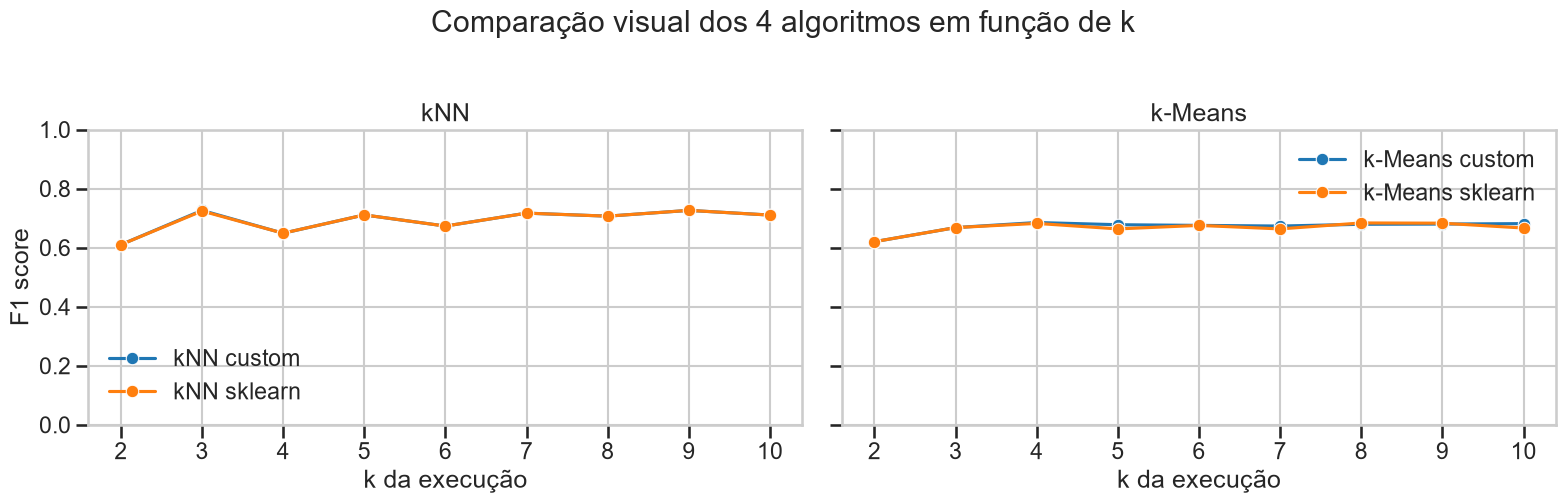

In [15]:
def cluster_purity(cluster_summary):
    cluster_df = pd.DataFrame(cluster_summary).fillna(0)
    if cluster_df.empty:
        return 0.0
    return float(cluster_df.max(axis=1).sum() / cluster_df.sum().sum())

comparison_rows = []

for row in knn_custom:
    comparison_rows.append({
        'family': 'kNN',
        'algorithm': 'kNN custom',
        'k': row['k'],
        'score': row['f1']
    })

for row in knn_sklearn:
    comparison_rows.append({
        'family': 'kNN',
        'algorithm': 'kNN sklearn',
        'k': row['k'],
        'score': row['f1']
    })

for row in kmeans_custom:
    comparison_rows.append({
        'family': 'k-Means',
        'algorithm': 'k-Means custom',
        'k': row['k'],
        'score': cluster_purity(row['cluster_summary'])
    })

for row in kmeans_sklearn:
    comparison_rows.append({
        'family': 'k-Means',
        'algorithm': 'k-Means sklearn',
        'k': row['k'],
        'score': cluster_purity(row['cluster_summary'])
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(['family', 'algorithm', 'k'])
display(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, family, ylabel in zip(axes, ['kNN', 'k-Means'], ['F1 score', 'Cluster purity']):
    family_df = comparison_df[comparison_df['family'] == family]
    sns.lineplot(
        data=family_df,
        x='k',
        y='score',
        hue='algorithm',
        marker='o',
        dashes=False,
        ax=ax,
    )
    ax.set_title(family)
    ax.set_xlabel('k da execução')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)
    ax.legend(title='')

plt.suptitle('Comparação visual dos 4 algoritmos em função de k', y=1.02)
plt.tight_layout()

,GP,MIN,PTS,FGM,FGA,FG%,3PMade,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV
0,0.746469,1.174014,1.142876,1.136565,1.127279,0.301513,0.374881,0.386599,0.118506,1.018704,1.016872,0.236367,0.795592,0.926519,0.915052,0.724857,0.893325,0.567229,1.044701
1,-0.352727,-0.554754,-0.540040,-0.537058,-0.532670,-0.142473,-0.177141,-0.182679,-0.055997,-0.481366,-0.480500,-0.111690,-0.375939,-0.437806,-0.432387,-0.342515,-0.422121,-0.268031,-0.493650


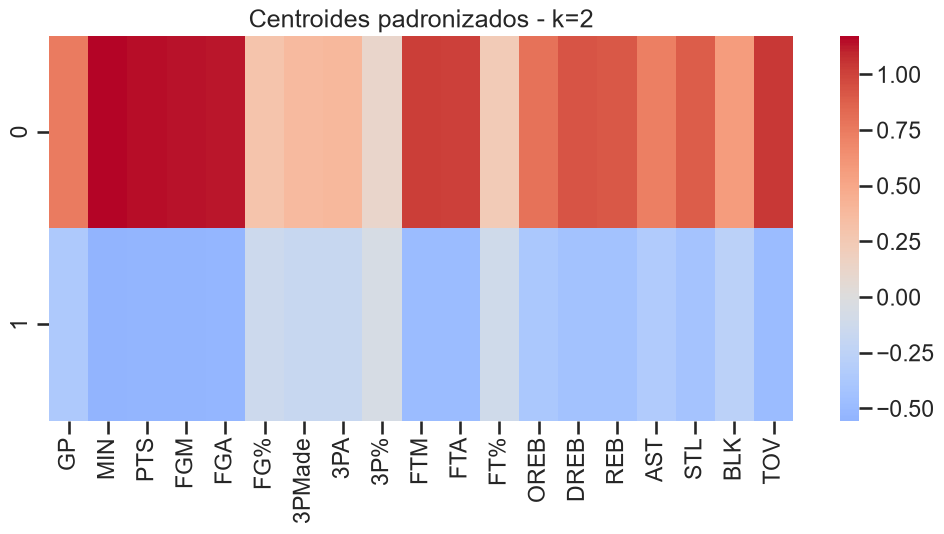

,GP,MIN,PTS,FGM,FGA,FG%,3PMade,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV
0,0.858803,1.798188,2.016208,1.987434,1.955273,0.375399,0.510607,0.550111,0.114687,1.919767,1.918791,0.278212,1.335713,1.572158,1.546132,1.170191,1.389122,0.996181,1.847498
1,0.560115,0.428424,0.252538,0.259283,0.255755,0.226546,0.161468,0.148526,0.104364,0.163814,0.163500,0.162648,0.229139,0.282307,0.271956,0.201434,0.322420,0.132434,0.225548
2,-0.675585,-0.812639,-0.726933,-0.724927,-0.713737,-0.280520,-0.262949,-0.262726,-0.114127,-0.630184,-0.629678,-0.203653,-0.531587,-0.635881,-0.620764,-0.466271,-0.620865,-0.365361,-0.661368


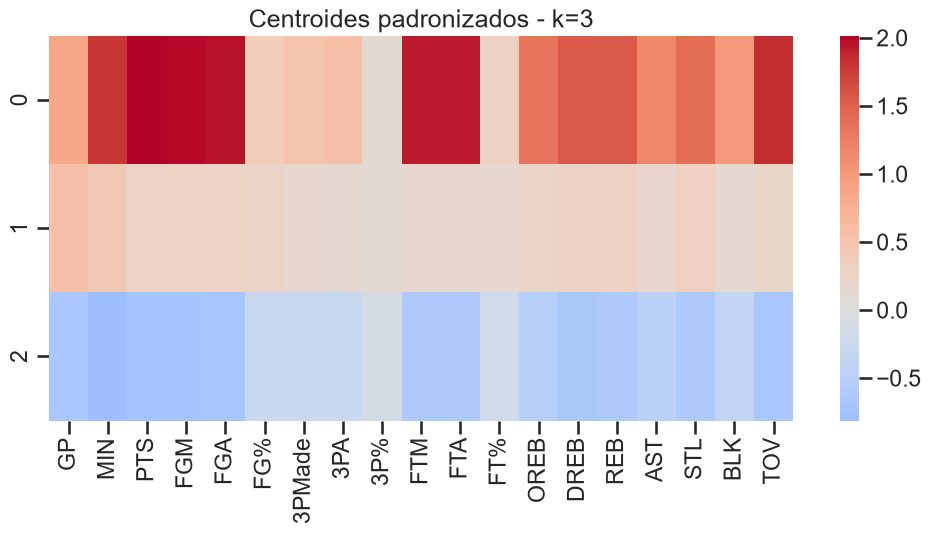

,GP,MIN,PTS,FGM,FGA,FG%,3PMade,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV
0,0.871764,1.781490,2.142140,2.128947,1.989192,0.628802,-0.077340,-0.036750,-0.150107,2.218606,2.284817,0.119271,1.930924,2.065162,2.099417,0.704912,1.162983,1.494139,1.885682
1,-0.666006,-0.801412,-0.718901,-0.723470,-0.685808,-0.480922,-0.170867,-0.160442,0.093406,-0.636355,-0.650514,-0.119132,-0.645181,-0.715075,-0.717231,-0.379700,-0.562902,-0.469616,-0.628644
2,0.638063,0.875219,0.702119,0.666242,0.797017,-0.214161,1.041149,1.050165,0.686745,0.421449,0.317761,0.590822,-0.240225,0.096400,-0.026021,1.026561,0.899810,-0.253488,0.732228
3,0.325357,0.038236,-0.083943,-0.039308,-0.173587,0.832843,-0.587475,-0.628508,-0.723205,-0.010780,0.083167,-0.351008,0.692412,0.472694,0.572907,-0.474706,-0.194460,0.542384,-0.182529


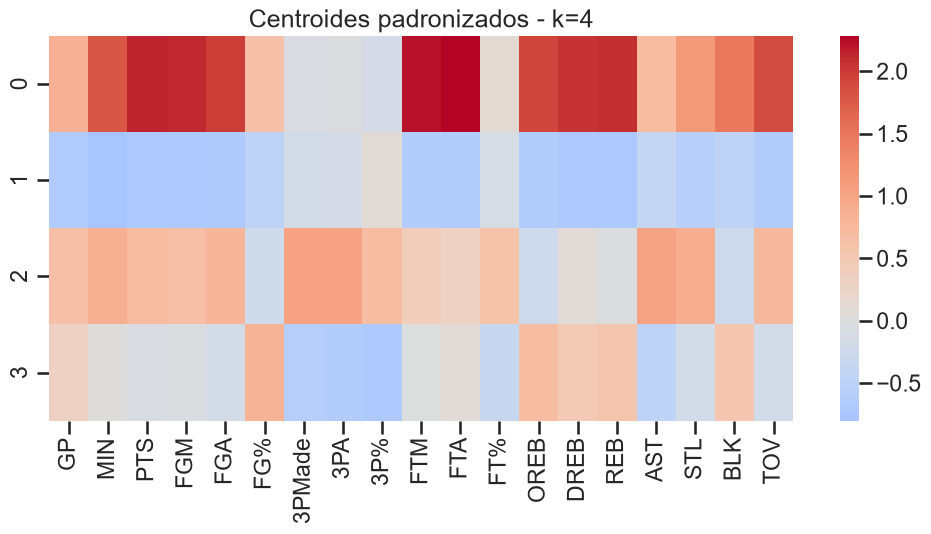

,GP,MIN,PTS,FGM,FGA,FG%,3PMade,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV
0,-0.726188,-0.812355,-0.729275,-0.745226,-0.677665,-0.745616,-0.071279,-0.044336,0.383200,-0.645796,-0.683517,0.085448,-0.757791,-0.788684,-0.808101,-0.317966,-0.538463,-0.549216,-0.618091
1,0.725133,0.862689,0.727206,0.778259,0.599041,0.837627,-0.557687,-0.588178,-0.556435,0.767239,0.888628,-0.155064,1.516454,1.375272,1.482227,-0.206488,0.263127,1.255045,0.524719
2,0.593831,0.637512,0.444832,0.416435,0.534489,-0.221589,0.863878,0.878358,0.666862,0.206670,0.117477,0.528986,-0.302167,-0.013615,-0.123105,0.766865,0.703290,-0.296428,0.465232
3,-0.208601,-0.539599,-0.523560,-0.485094,-0.588361,0.670574,-0.621887,-0.670406,-0.927979,-0.414643,-0.331194,-0.637294,0.148611,-0.095838,-0.007480,-0.666329,-0.576367,0.130485,-0.554153
4,0.871871,2.064315,2.504745,2.439606,2.438449,0.291458,0.777069,0.832694,0.354984,2.426547,2.371033,0.425214,1.196823,1.536141,1.470204,1.766128,1.812382,0.744858,2.401701


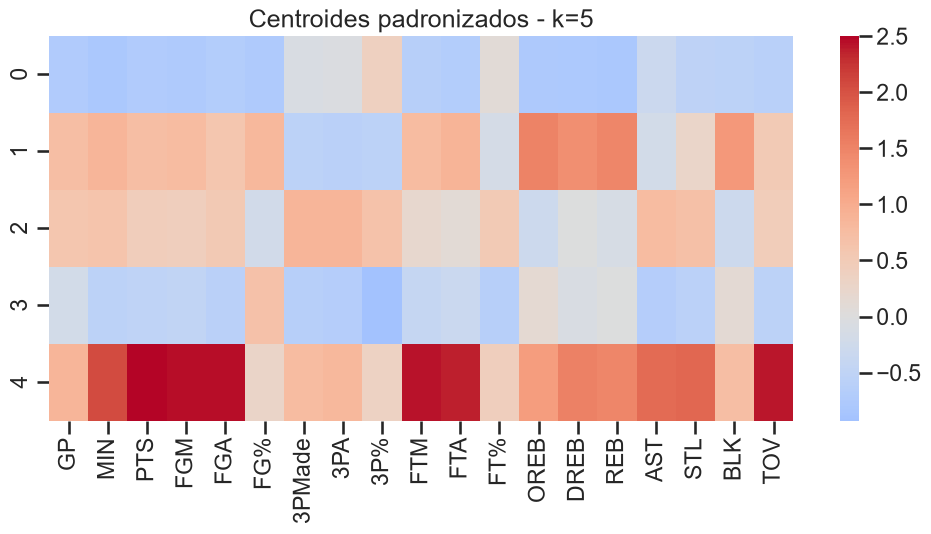

,GP,MIN,PTS,FGM,FGA,FG%,3PMade,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV
0,0.735649,1.782318,1.816327,1.701650,1.920688,-0.199082,1.708927,1.798082,0.713603,1.554343,1.390773,0.641482,0.103489,0.494456,0.365209,2.106905,1.785845,-0.119460,1.909072
1,-0.794568,-0.808006,-0.736110,-0.758148,-0.674066,-0.873210,0.023659,0.063982,0.588761,-0.671027,-0.717347,0.163429,-0.796824,-0.797696,-0.829779,-0.306349,-0.556168,-0.563193,-0.625016
2,-0.514815,-0.822319,-0.715049,-0.683860,-0.760685,0.416332,-0.627519,-0.671263,-0.982463,-0.574533,-0.518943,-0.631566,-0.185866,-0.437943,-0.357222,-0.680228,-0.713942,-0.126048,-0.714904
3,0.523741,0.420983,0.240549,0.225339,0.314956,-0.206446,0.622735,0.619554,0.682247,0.053009,-0.023154,0.487089,-0.357168,-0.109607,-0.207674,0.519314,0.506668,-0.323443,0.269926
4,0.904366,1.787251,2.155919,2.190170,1.951048,0.804855,-0.479376,-0.493833,-0.376398,2.218931,2.346376,0.019358,2.309834,2.464512,2.506931,0.426336,0.992399,1.912308,1.743000
5,0.590485,0.388663,0.220836,0.269337,0.120475,0.831779,-0.557149,-0.589226,-0.621831,0.263480,0.381804,-0.306391,1.050047,0.850454,0.956597,-0.346489,0.032252,0.809713,0.120501


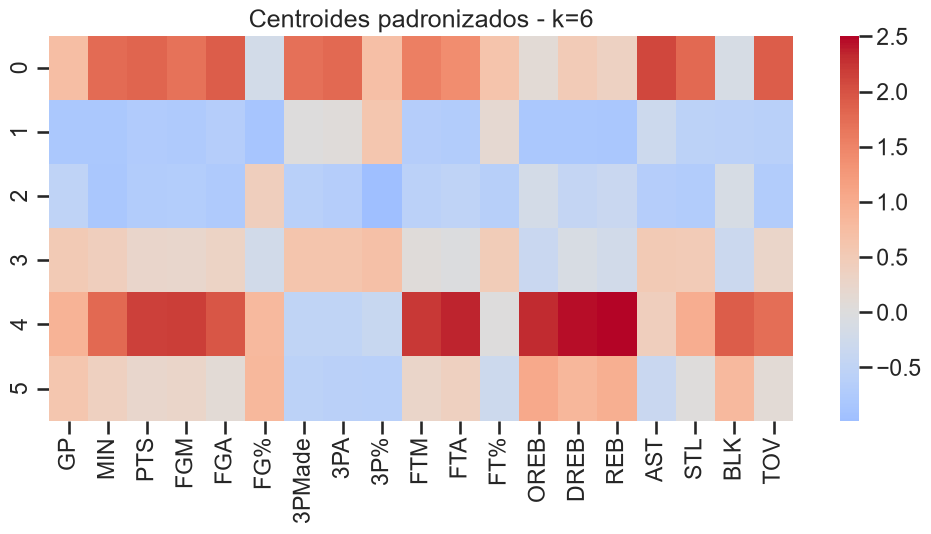

,GP,MIN,PTS,FGM,FGA,FG%,3PMade,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV
0,0.762187,0.682956,0.520238,0.570214,0.611639,0.032075,-0.250828,-0.190036,0.110885,0.447624,0.365744,0.494650,-0.166216,-0.108553,-0.131450,1.260012,1.149713,-0.383215,0.890300
1,0.575161,0.324642,0.167658,0.215185,0.059641,0.857186,-0.573499,-0.607298,-0.635066,0.221347,0.342668,-0.326349,1.058655,0.850181,0.959110,-0.423544,-0.056434,0.836130,0.050996
2,0.700113,1.872519,1.963093,1.791978,2.046654,-0.262064,2.165573,2.255307,0.866370,1.713257,1.543210,0.672730,0.146331,0.600634,0.451308,1.948936,1.713856,-0.028380,1.913491
3,0.900135,1.790250,2.164324,2.197052,1.957721,0.805283,-0.477272,-0.491984,-0.379230,2.230315,2.356186,0.024032,2.318043,2.488499,2.525954,0.423560,0.977720,1.938539,1.747425
4,0.307865,0.337274,0.149998,0.096976,0.220947,-0.381506,1.243672,1.199906,1.009932,-0.147312,-0.217842,0.474503,-0.421395,-0.064958,-0.204737,0.153252,0.177670,-0.265128,-0.025195
5,-0.512277,-0.817085,-0.713647,-0.681757,-0.760714,0.436412,-0.627091,-0.671369,-0.982990,-0.575509,-0.518305,-0.640367,-0.183452,-0.433439,-0.353284,-0.674368,-0.709963,-0.127611,-0.709569
6,-0.802281,-0.837311,-0.757864,-0.775126,-0.696719,-0.866441,-0.084206,-0.040645,0.535959,-0.667710,-0.711430,0.129809,-0.793366,-0.815468,-0.839993,-0.308595,-0.559851,-0.566012,-0.630156


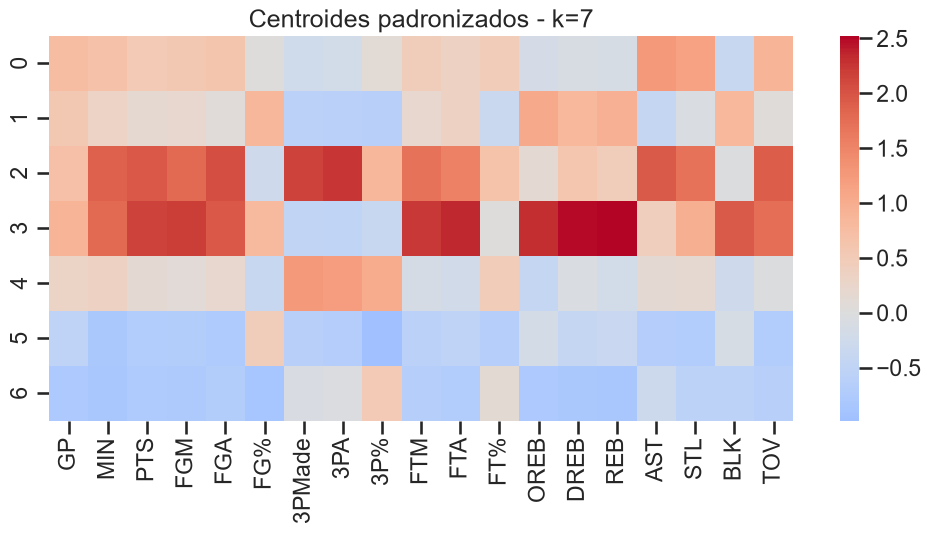

,GP,MIN,PTS,FGM,FGA,FG%,3PMade,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV
0,0.545473,0.331850,0.158645,0.205606,0.049382,0.872558,-0.582029,-0.620173,-0.727509,0.217607,0.346437,-0.366157,1.100340,0.871424,0.989387,-0.427122,-0.045184,0.870176,0.048837
1,0.282513,0.496976,0.285282,0.209584,0.357135,-0.434448,1.617987,1.566750,0.998500,-0.081220,-0.163892,0.549319,-0.414172,0.010676,-0.150924,0.242497,0.273463,-0.241664,0.071819
2,0.890692,1.737665,2.086735,2.121084,1.868920,0.842420,-0.510275,-0.528953,-0.414177,2.162334,2.301629,-0.009844,2.319672,2.484775,2.524108,0.344371,0.897371,1.988713,1.679075
3,0.807505,0.868185,0.681588,0.733469,0.783813,0.041978,-0.214824,-0.147506,0.100144,0.586532,0.505481,0.464583,-0.053521,0.018160,-0.004925,1.452744,1.345337,-0.307913,1.097241
4,-1.161936,-0.947153,-0.850052,-0.877259,-0.779497,-1.138824,0.004576,0.053802,0.431290,-0.760408,-0.797306,-0.007011,-0.859431,-0.863130,-0.896332,-0.396726,-0.662222,-0.579005,-0.744715
5,0.788329,1.949706,2.120335,1.956780,2.208361,-0.236327,2.121004,2.220481,0.858153,1.862870,1.701549,0.641581,0.245352,0.706410,0.559184,1.947991,1.792627,0.034394,2.051056
6,-0.549137,-0.846303,-0.741609,-0.711359,-0.794438,0.483542,-0.636667,-0.689651,-1.060494,-0.596002,-0.528931,-0.712624,-0.171669,-0.427554,-0.344677,-0.709686,-0.744177,-0.106714,-0.737072
7,0.213093,-0.336433,-0.343444,-0.326062,-0.310648,-0.091839,-0.244380,-0.224300,0.587082,-0.304421,-0.359792,0.361830,-0.471765,-0.497895,-0.509786,-0.024419,-0.160006,-0.440977,-0.260432


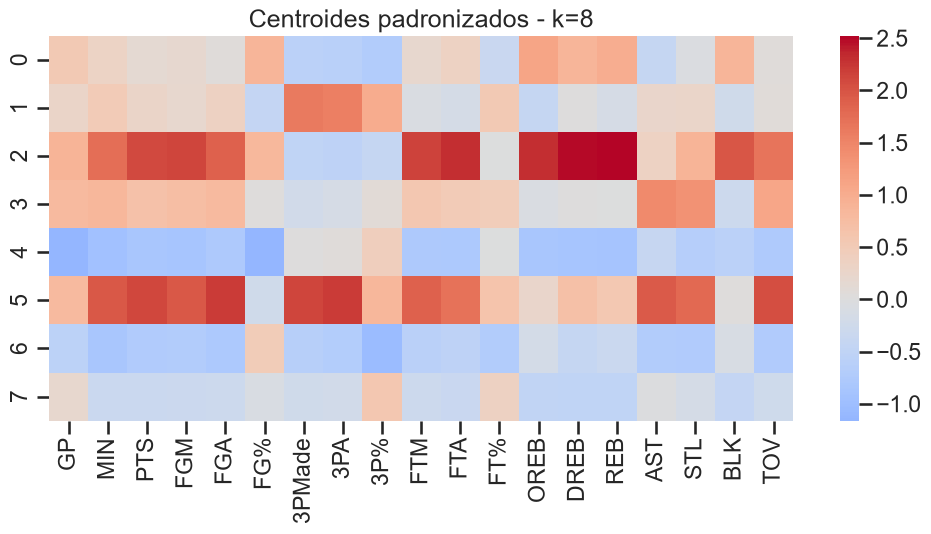

,GP,MIN,PTS,FGM,FGA,FG%,3PMade,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV
0,0.570616,0.347930,0.188881,0.238093,0.072424,0.907353,-0.585016,-0.622730,-0.760580,0.241851,0.380579,-0.391478,1.119145,0.897546,1.014452,-0.421740,-0.035319,0.908157,0.083706
1,0.387755,-0.204858,-0.273436,-0.254975,-0.208880,-0.271394,-0.224908,-0.168806,0.223673,-0.241966,-0.320441,0.520205,-0.620998,-0.559104,-0.606396,0.333171,0.077634,-0.569010,-0.057367
2,0.821902,0.952961,0.791795,0.848050,0.896817,0.069075,-0.195014,-0.124902,0.135950,0.669349,0.584658,0.492087,0.007892,0.049619,0.039405,1.489341,1.374605,-0.275355,1.174304
3,0.776284,1.940474,2.108775,1.931692,2.192994,-0.256959,2.170253,2.269904,0.865399,1.879838,1.717152,0.642486,0.230641,0.675645,0.532581,1.937603,1.820722,0.046607,2.056001
4,0.889039,1.793858,2.137100,2.171875,1.932642,0.794625,-0.491212,-0.509700,-0.394651,2.200932,2.326477,0.024360,2.352433,2.538117,2.571953,0.388847,0.950639,1.996829,1.701282
5,-0.126922,-0.432658,-0.400160,-0.387169,-0.431314,0.301846,-0.255965,-0.291597,1.162316,-0.355156,-0.341140,-0.120521,-0.052603,-0.202416,-0.157142,-0.534029,-0.412761,-0.136328,-0.526255
6,0.294186,0.525525,0.297158,0.219166,0.370379,-0.445577,1.665230,1.607000,1.004421,-0.077470,-0.162123,0.548200,-0.409752,0.030939,-0.135633,0.246489,0.289251,-0.234965,0.079060
7,-1.135755,-0.944582,-0.844692,-0.871956,-0.772834,-1.138720,0.005140,0.051804,0.426846,-0.752562,-0.791958,0.027948,-0.862785,-0.869741,-0.901947,-0.397013,-0.666716,-0.587367,-0.738756
8,-0.556168,-0.852314,-0.742988,-0.711696,-0.797110,0.496255,-0.641499,-0.696385,-1.109749,-0.598879,-0.534330,-0.709057,-0.174655,-0.429989,-0.347339,-0.715940,-0.754618,-0.103216,-0.740385


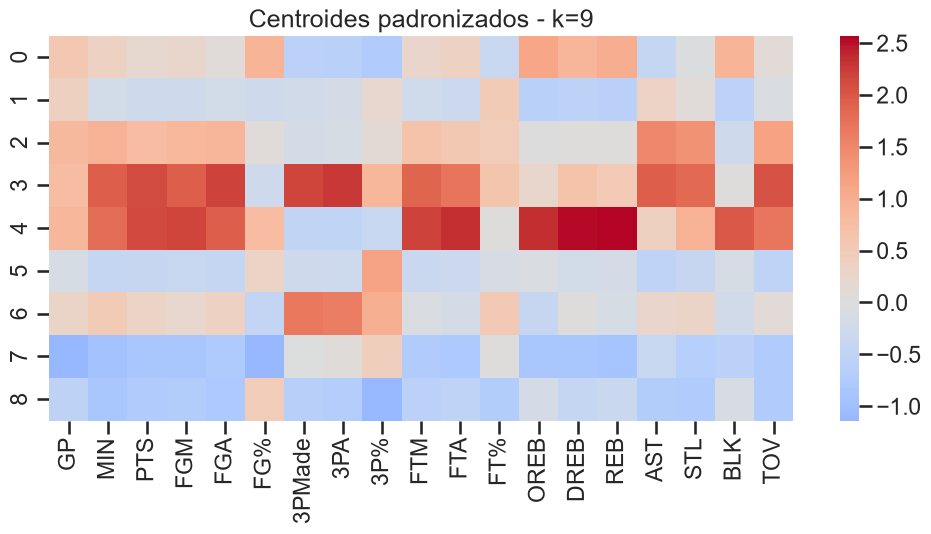

,GP,MIN,PTS,FGM,FGA,FG%,3PMade,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV
0,0.203349,0.340418,0.142859,0.076615,0.218235,-0.475317,1.432927,1.393905,0.989472,-0.186143,-0.263000,0.553882,-0.445100,-0.067804,-0.215638,0.107349,0.134078,-0.241431,-0.055015
1,0.505248,0.188403,0.049906,0.095180,-0.040222,0.791242,-0.581738,-0.614864,-0.761505,0.116082,0.229930,-0.344618,0.906728,0.686979,0.793313,-0.456917,-0.107463,0.725152,-0.036323
2,-0.586761,-0.934845,-0.757600,-0.759186,-0.786682,-0.040012,-0.622917,-0.636446,-0.928068,-0.508710,-0.567264,0.368919,-0.509294,-0.696937,-0.650157,-0.529561,-0.708600,-0.464029,-0.673343
3,0.666489,1.603464,1.568517,1.402676,1.670309,-0.358143,2.728513,2.690765,1.014670,1.076737,0.938604,0.632596,-0.078362,0.388868,0.227026,1.466613,1.344244,-0.132476,1.336398
4,0.913858,2.186985,2.921092,2.828559,2.789127,0.359401,0.253084,0.382427,0.242082,3.143564,3.070750,0.420895,1.792832,2.148630,2.104686,1.438465,1.778054,1.303548,2.615911
5,-1.168976,-0.932765,-0.852004,-0.878750,-0.775385,-1.179601,0.045638,0.101557,0.524407,-0.779544,-0.810722,-0.077353,-0.868298,-0.857140,-0.894759,-0.393640,-0.647010,-0.572004,-0.745840
6,0.239941,-0.297909,-0.320279,-0.298276,-0.291321,-0.020328,-0.264208,-0.250488,0.693215,-0.289787,-0.333931,0.280403,-0.442797,-0.479057,-0.486096,-0.005781,-0.107517,-0.430273,-0.256972
7,0.822067,1.361846,1.334013,1.400724,1.146846,0.966018,-0.584431,-0.622413,-0.519821,1.332140,1.506910,-0.162076,2.084103,2.054264,2.147477,-0.027639,0.524470,1.685229,1.031039
8,-0.600992,-0.838748,-0.762494,-0.715384,-0.816682,0.671838,-0.633502,-0.696011,-1.063257,-0.676095,-0.538884,-1.355966,-0.059845,-0.341904,-0.247599,-0.767027,-0.793763,0.054725,-0.755811
9,0.840498,0.924522,0.715599,0.764635,0.818307,0.031959,-0.172590,-0.098773,0.133132,0.613909,0.522752,0.499335,-0.111214,0.029883,-0.018482,1.625893,1.428282,-0.324976,1.180216


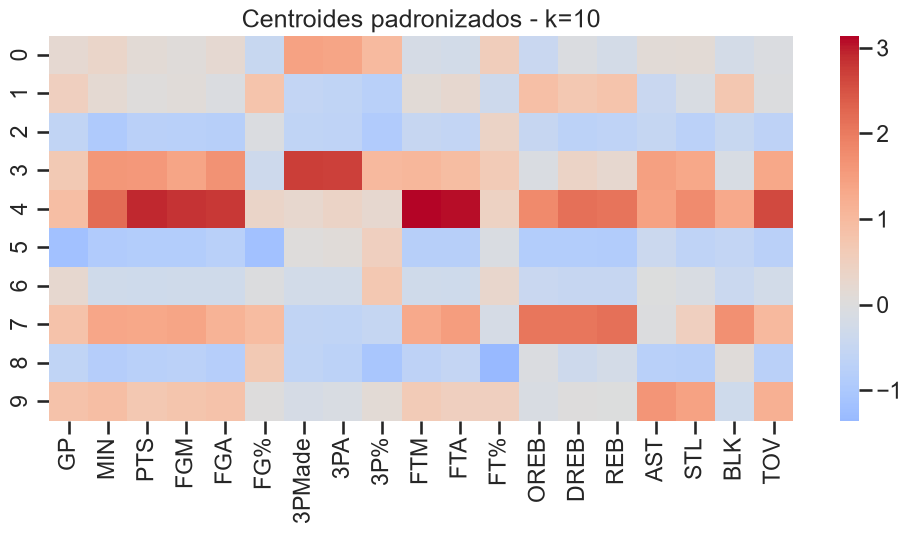

In [16]:
for result in kmeans_custom:
    centroid_df = pd.DataFrame(result['centroids_scaled'])
    display(centroid_df)
    plt.figure(figsize=(12, 5))
    sns.heatmap(centroid_df, annot=False, cmap='coolwarm', center=0)
    plt.title(f"Centroides padronizados - k={result['k']}")
    plt.show()